# 05 - EDA from Scraped CSVs


In [1]:
# pandas is used for tables and calculations.
# matplotlib is used for simple inline notebook charts.
!pip -q install pandas matplotlib

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Force charts to render inside the notebook output cells.
# Colab normally does this by default, but this line makes the intention explicit.
%matplotlib inline

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

plt.rcParams["figure.figsize"] = (10, 5)

# Read directly from Colab's content directory
DATA_DIR = Path("/content/data")

print("Using data folder:", DATA_DIR.resolve())

Using data folder: /content/data


## 1. Load the CSV Files

Each CSV came from one scraping notebook:

- SmartCentres PDFs and website distributions
- yfinance market data
- Bank of Canada macro data
- WOWA competitor table

This notebook starts from those CSVs only.

In [3]:
stock_prices = pd.read_csv(DATA_DIR / "yfinance_stock_prices.csv")
company_profile = pd.read_csv(DATA_DIR / "yfinance_company_profile.csv")
yfinance_dividends = pd.read_csv(DATA_DIR / "yfinance_dividends.csv")
financials = pd.read_csv(DATA_DIR / "smartcentres_financials_from_pdfs.csv")
properties = pd.read_csv(DATA_DIR / "smartcentres_properties.csv")
smartcentres_distributions = pd.read_csv(DATA_DIR / "smartcentres_distributions.csv")
macro = pd.read_csv(DATA_DIR / "bank_of_canada_macro.csv")
competitors = pd.read_csv(DATA_DIR / "wowa_competitors.csv")

loaded_files = pd.DataFrame([
    {"DataFrame": "stock_prices", "Rows": len(stock_prices), "Columns": len(stock_prices.columns)},
    {"DataFrame": "company_profile", "Rows": len(company_profile), "Columns": len(company_profile.columns)},
    {"DataFrame": "yfinance_dividends", "Rows": len(yfinance_dividends), "Columns": len(yfinance_dividends.columns)},
    {"DataFrame": "financials", "Rows": len(financials), "Columns": len(financials.columns)},
    {"DataFrame": "properties", "Rows": len(properties), "Columns": len(properties.columns)},
    {"DataFrame": "smartcentres_distributions", "Rows": len(smartcentres_distributions), "Columns": len(smartcentres_distributions.columns)},
    {"DataFrame": "macro", "Rows": len(macro), "Columns": len(macro.columns)},
    {"DataFrame": "competitors", "Rows": len(competitors), "Columns": len(competitors.columns)},
])
display(loaded_files)

,DataFrame,Rows,Columns
0,stock_prices,6930,9
1,company_profile,5,14
2,yfinance_dividends,66,5
3,financials,169,9
4,properties,50,9
5,smartcentres_distributions,6,7
6,macro,5953,5
7,competitors,5,10


## 2. Stock Performance

Stock analysis uses `yfinance_stock_prices.csv`.

Finance meaning:
- Adjusted close is used because it is better for return analysis.
- Monthly returns show whether the stock was rising or falling month to month.
- Indexed performance lets different REITs be compared from the same starting value of 100.

In [4]:
SMARTCENTRES_TICKER = "SRU-UN.TO"

stock_prices["Date"] = pd.to_datetime(stock_prices["Date"], errors="coerce", utc=True).dt.tz_convert(None)
stock_prices = stock_prices.sort_values(["ticker", "Date"]).copy()
stock_prices["daily_return"] = stock_prices.groupby("ticker")["Adj Close"].pct_change()
stock_prices["indexed_price"] = stock_prices.groupby("ticker")["Adj Close"].transform(lambda s: s / s.iloc[0] * 100)

smart_stock = stock_prices[stock_prices["ticker"] == SMARTCENTRES_TICKER].copy()
smart_stock["ma_50"] = smart_stock["Adj Close"].rolling(50).mean()
smart_stock["ma_200"] = smart_stock["Adj Close"].rolling(200).mean()

monthly_prices = (
    stock_prices.set_index("Date")
    .groupby("ticker")
    .resample("ME")["Adj Close"]
    .last()
    .reset_index()
    .sort_values(["ticker", "Date"])
)
monthly_prices["monthly_return"] = monthly_prices.groupby("ticker")["Adj Close"].pct_change()
monthly_prices["year"] = monthly_prices["Date"].dt.year

annual_returns = (
    monthly_prices.dropna(subset=["monthly_return"])
    .assign(one_plus_return=lambda df: 1 + df["monthly_return"])
    .groupby(["ticker", "year"], as_index=False)["one_plus_return"]
    .prod()
)
annual_returns["annual_return"] = annual_returns["one_plus_return"] - 1
annual_returns = annual_returns.drop(columns=["one_plus_return"])
display(annual_returns.head(10))

,ticker,year,annual_return
0,AP-UN.TO,2021,0.256006
1,AP-UN.TO,2022,-0.386166
2,AP-UN.TO,2023,-0.121395
3,AP-UN.TO,2024,-0.059192
4,AP-UN.TO,2025,-0.134749
5,AP-UN.TO,2026,-0.205332
6,CHP-UN.TO,2021,0.231928
7,CHP-UN.TO,2022,0.024101
8,CHP-UN.TO,2023,-0.001223
9,CHP-UN.TO,2024,0.011153


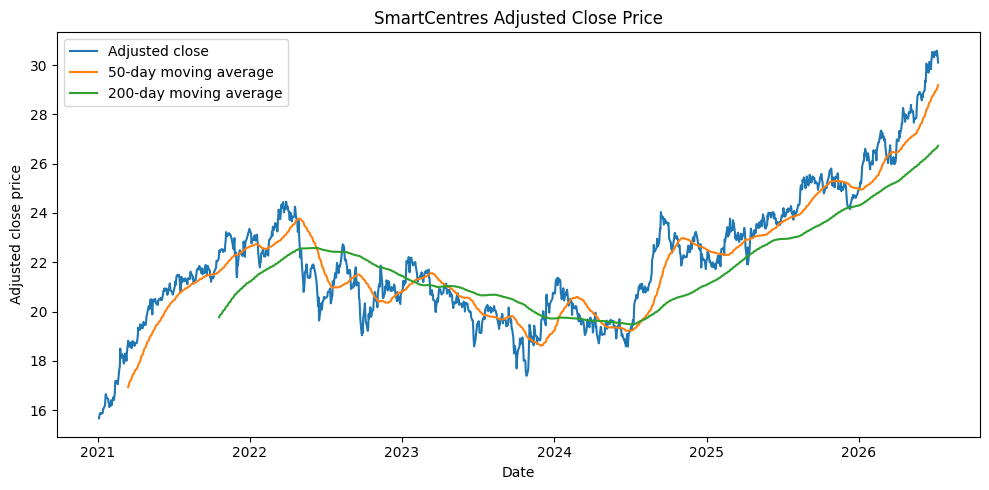

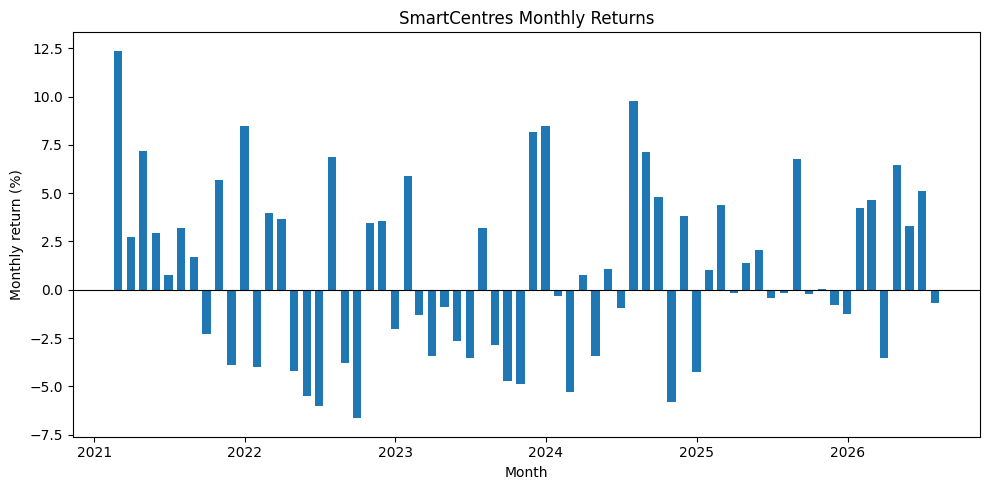

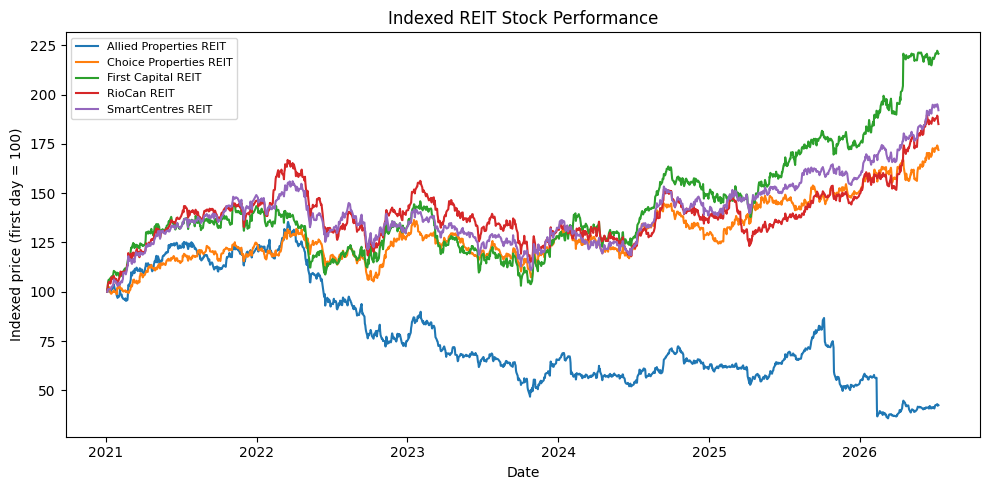

In [5]:
plt.figure()
plt.plot(smart_stock["Date"], smart_stock["Adj Close"], label="Adjusted close")
plt.plot(smart_stock["Date"], smart_stock["ma_50"], label="50-day moving average")
plt.plot(smart_stock["Date"], smart_stock["ma_200"], label="200-day moving average")
plt.title("SmartCentres Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Adjusted close price")
plt.legend()
plt.tight_layout()
plt.show()

smart_monthly = monthly_prices[monthly_prices["ticker"] == SMARTCENTRES_TICKER].dropna(subset=["monthly_return"])
plt.figure()
plt.bar(smart_monthly["Date"], smart_monthly["monthly_return"] * 100, width=20)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("SmartCentres Monthly Returns")
plt.xlabel("Month")
plt.ylabel("Monthly return (%)")
plt.tight_layout()
plt.show()

plt.figure()
for ticker, group in stock_prices.groupby("ticker"):
    label = group["company_name"].iloc[0]
    plt.plot(group["Date"], group["indexed_price"], label=label)
plt.title("Indexed REIT Stock Performance")
plt.xlabel("Date")
plt.ylabel("Indexed price (first day = 100)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Dividends and Distributions

Dividend analysis uses `yfinance_dividends.csv` for the longer history.

The SmartCentres website distribution CSV is still useful as an official source, but the visible company table only covers the current selected year. For annual trend analysis, yfinance gives a longer monthly history.

,year,payment_count,annual_distribution_per_unit,average_payment,distribution_growth,is_partial_year
0,2021,12,1.848,0.154,NaN,False
1,2022,12,1.848,0.154,0.0,False
2,2023,12,1.848,0.154,0.0,False
3,2024,12,1.848,0.154,0.0,False
4,2025,12,1.848,0.154,0.0,False
5,2026,6,0.924,0.154,-0.5,True


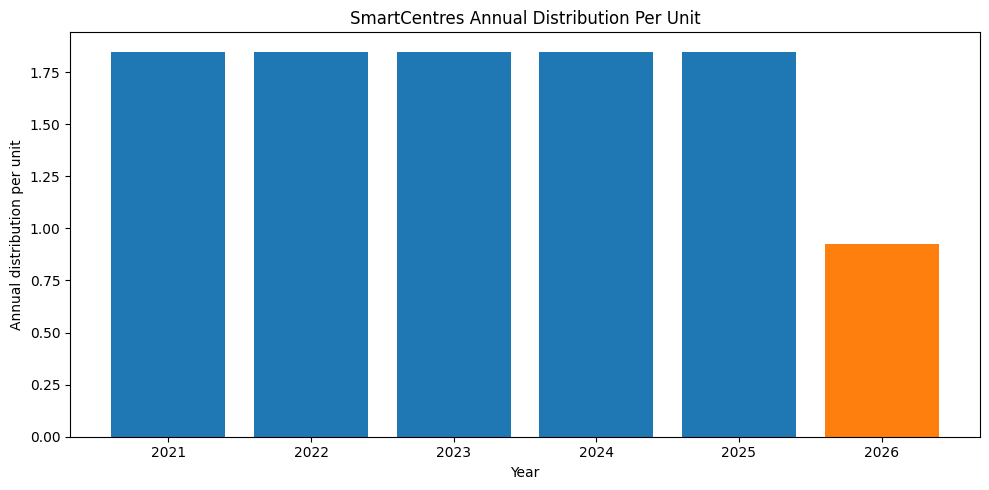

In [6]:
yfinance_dividends["dividend_amount"] = pd.to_numeric(yfinance_dividends["dividend_amount"], errors="coerce")
yfinance_dividends["dividend_date"] = pd.to_datetime(yfinance_dividends["dividend_date"], errors="coerce", utc=True).dt.tz_convert(None)
yfinance_dividends["year"] = yfinance_dividends["dividend_date"].dt.year

annual_dividends = (
    yfinance_dividends.dropna(subset=["year", "dividend_amount"])
    .groupby("year", as_index=False)
    .agg(
        payment_count=("dividend_amount", "count"),
        annual_distribution_per_unit=("dividend_amount", "sum"),
        average_payment=("dividend_amount", "mean"),
    )
)
annual_dividends["distribution_growth"] = annual_dividends["annual_distribution_per_unit"].pct_change()
annual_dividends["is_partial_year"] = annual_dividends["payment_count"] < 12
display(annual_dividends)

colors = annual_dividends["is_partial_year"].map({True: "tab:orange", False: "tab:blue"})
plt.figure()
plt.bar(annual_dividends["year"].astype(str), annual_dividends["annual_distribution_per_unit"], color=colors)
plt.title("SmartCentres Annual Distribution Per Unit")
plt.xlabel("Year")
plt.ylabel("Annual distribution per unit")
plt.tight_layout()
plt.show()

## 4. Financial Performance from SmartCentres PDFs

These rows come from `smartcentres_financials_from_pdfs.csv`.

Important unit note:
SmartCentres financial statement values are often reported in **thousands of Canadian dollars**. For charts, this notebook converts those values into **CAD millions** so the scale is easier to read.

In [7]:
financials["period"] = pd.to_numeric(financials["period"], errors="coerce").astype("Int64")
financials["value_numeric"] = pd.to_numeric(financials["value_numeric"], errors="coerce")

financial_summary = (
    financials.dropna(subset=["period", "metric_or_line_item", "value_numeric"])
    .groupby(["metric_or_line_item", "period"], as_index=False)
    .agg(value=("value_numeric", "median"))
    .sort_values(["metric_or_line_item", "period"])
)
financial_summary["yoy_growth"] = financial_summary.groupby("metric_or_line_item")["value"].pct_change()

def metric_series(summary, metric_name):
    return summary[summary["metric_or_line_item"] == metric_name].dropna(subset=["period", "value"]).copy()

def thousands_to_millions(series):
    return pd.to_numeric(series, errors="coerce") / 1000

display(financial_summary.head(15))

,metric_or_line_item,period,value,yoy_growth
0,Adjusted Debt to Adjusted EBITDA,2023,9.6,NaN
1,Adjusted Debt to Adjusted EBITDA,2024,9.6,0.000000
2,Adjusted Debt to Adjusted EBITDA,2025,9.7,0.010417
3,Cash and cash equivalents,2021,62235.0,NaN
4,Cash and cash equivalents,2022,35255.0,-0.433518
5,Cash and cash equivalents,2023,34999.0,-0.007261
6,Cash and cash equivalents,2024,36218.5,0.034844
7,Cash and cash equivalents,2025,51551.0,0.423333
8,Cash flows provided by operating activities,2021,371624.0,NaN
9,Cash flows provided by operating activities,2022,370762.0,-0.002320


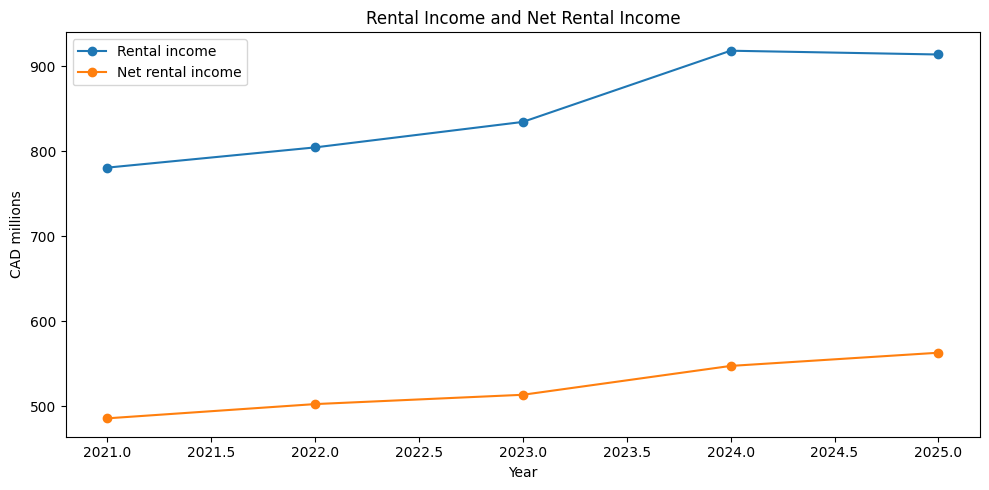

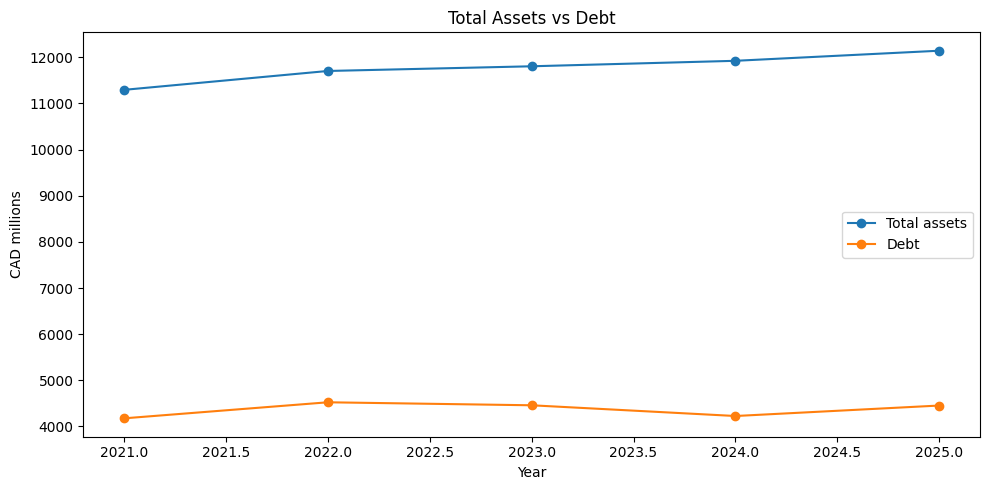

In [8]:
rental = metric_series(financial_summary, "Rentals from investment properties and other")
net_rental = metric_series(financial_summary, "Net rental income and other")
total_assets = metric_series(financial_summary, "Total assets")
debt = metric_series(financial_summary, "Debt")
operating_cash_flow = metric_series(financial_summary, "Cash flows provided by operating activities")
distributions_paid = metric_series(financial_summary, "Distributions paid on Trust Units")
net_income = metric_series(financial_summary, "Net income and comprehensive income")

plt.figure()
plt.plot(rental["period"], thousands_to_millions(rental["value"]), marker="o", label="Rental income")
plt.plot(net_rental["period"], thousands_to_millions(net_rental["value"]), marker="o", label="Net rental income")
plt.title("Rental Income and Net Rental Income")
plt.xlabel("Year")
plt.ylabel("CAD millions")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(total_assets["period"], thousands_to_millions(total_assets["value"]), marker="o", label="Total assets")
plt.plot(debt["period"], thousands_to_millions(debt["value"]), marker="o", label="Debt")
plt.title("Total Assets vs Debt")
plt.xlabel("Year")
plt.ylabel("CAD millions")
plt.legend()
plt.tight_layout()
plt.show()

,period,operating_cash_flow,distributions_paid,distributions_paid_abs,distributions_as_pct_of_operating_cash_flow,operating_cash_flow_cad_millions,distributions_paid_cad_millions
0,2021,371624.0,-267552.0,267552.0,71.995350,371.624,267.552
1,2022,370762.0,-267563.0,267563.0,72.165702,370.762,267.563
2,2023,330853.0,-267563.0,267563.0,80.870659,330.853,267.563
3,2024,374208.0,-267630.0,267630.0,71.519048,374.208,267.630
4,2025,377441.0,-267681.0,267681.0,70.919958,377.441,267.681


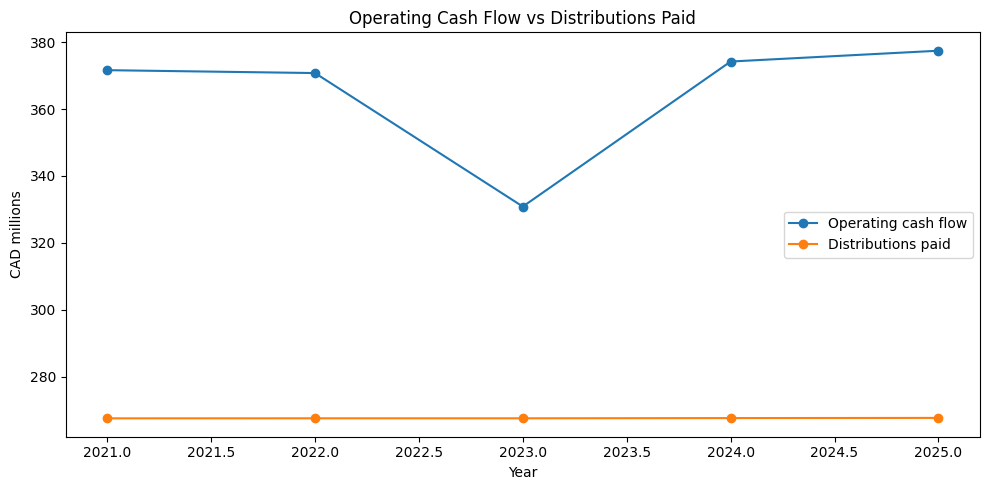

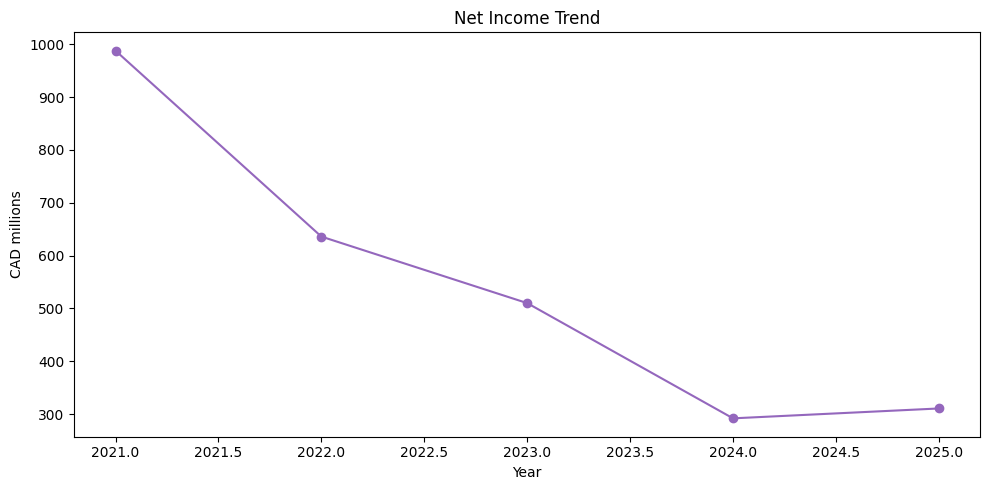

In [9]:
cashflow_table = pd.merge(
    operating_cash_flow[["period", "value"]].rename(columns={"value": "operating_cash_flow"}),
    distributions_paid[["period", "value"]].rename(columns={"value": "distributions_paid"}),
    on="period",
    how="outer",
).sort_values("period")
cashflow_table["distributions_paid_abs"] = cashflow_table["distributions_paid"].abs()
cashflow_table["distributions_as_pct_of_operating_cash_flow"] = (
    cashflow_table["distributions_paid_abs"] / cashflow_table["operating_cash_flow"] * 100
)
cashflow_table["operating_cash_flow_cad_millions"] = thousands_to_millions(cashflow_table["operating_cash_flow"])
cashflow_table["distributions_paid_cad_millions"] = thousands_to_millions(cashflow_table["distributions_paid_abs"])
display(cashflow_table)

plt.figure()
plt.plot(cashflow_table["period"], cashflow_table["operating_cash_flow_cad_millions"], marker="o", label="Operating cash flow")
plt.plot(cashflow_table["period"], cashflow_table["distributions_paid_cad_millions"], marker="o", label="Distributions paid")
plt.title("Operating Cash Flow vs Distributions Paid")
plt.xlabel("Year")
plt.ylabel("CAD millions")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(net_income["period"], thousands_to_millions(net_income["value"]), marker="o", color="tab:purple")
plt.title("Net Income Trend")
plt.xlabel("Year")
plt.ylabel("CAD millions")
plt.tight_layout()
plt.show()

### Operating Cash Flow Growth Analysis

To better understand the trend, let's look at the specific year-over-year growth percentages for operating cash flow.

In [18]:
ocf_trend = operating_cash_flow[['period', 'value', 'yoy_growth']].copy()
ocf_trend['value_millions'] = thousands_to_millions(ocf_trend['value'])
ocf_trend['growth_pct'] = ocf_trend['yoy_growth'] * 100

display(ocf_trend[['period', 'value_millions', 'growth_pct']])

,period,value_millions,growth_pct
8,2021,371.624,NaN
9,2022,370.762,-0.231955
10,2023,330.853,-10.764048
11,2024,374.208,13.104007
12,2025,377.441,0.863958


### Net Income Trend (5-Year)

Visualizing the net income and comprehensive income from 2021 to 2025.

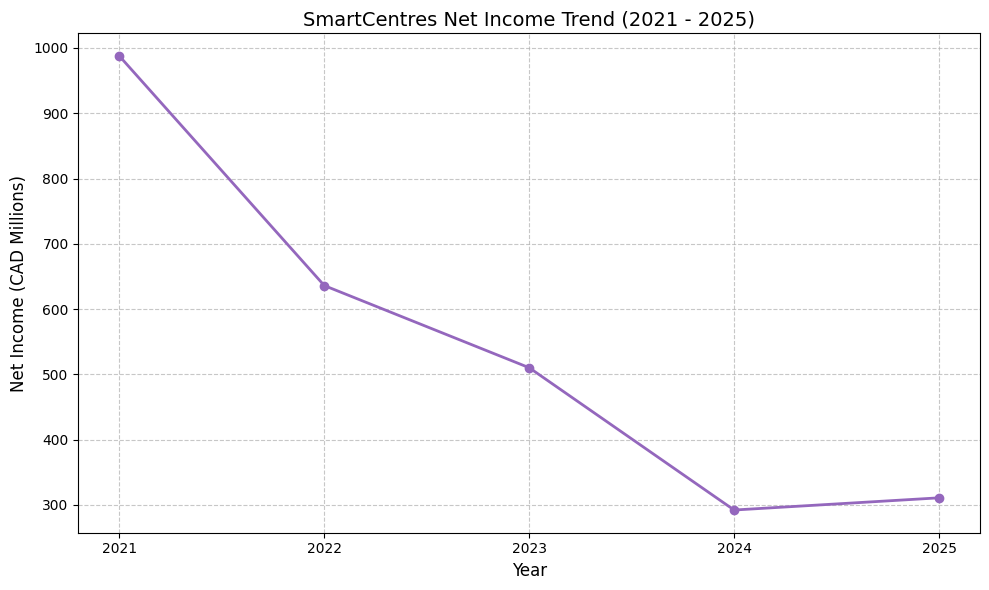

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(
    net_income["period"],
    thousands_to_millions(net_income["value"]),
    marker="o",
    linewidth=2,
    color="tab:purple",
    label="Net Income"
)

plt.title("SmartCentres Net Income Trend (2021 - 2025)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Net Income (CAD Millions)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(net_income["period"].astype(int))
plt.tight_layout()
plt.show()

### Operating Cash Flow Trend (5-Year)

Visualizing the cash flows provided by operating activities from 2021 to 2025 in CAD millions.

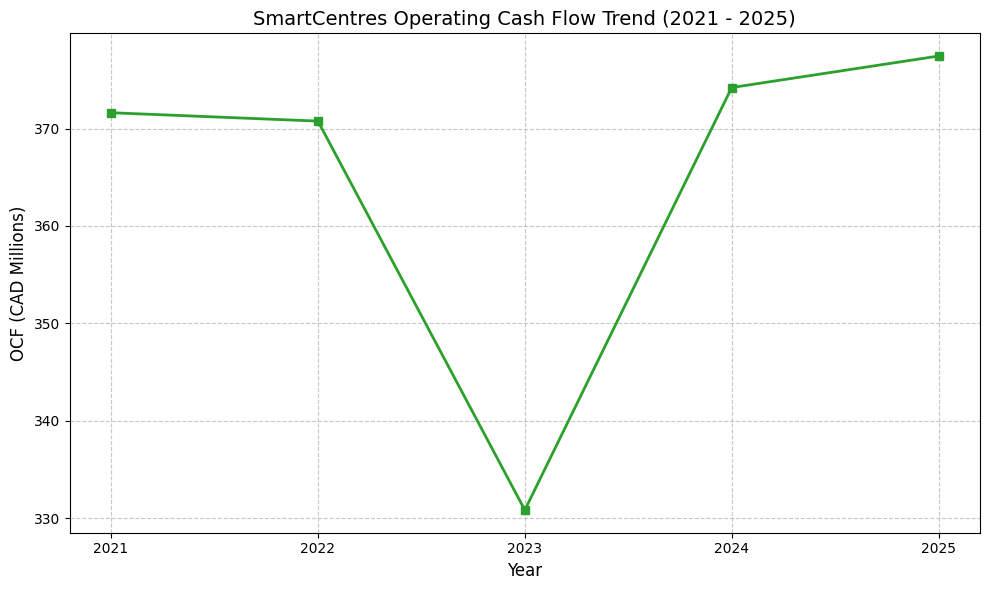

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(
    operating_cash_flow["period"],
    thousands_to_millions(operating_cash_flow["value"]),
    marker="s",
    linewidth=2,
    color="tab:green",
    label="Operating Cash Flow"
)

plt.title("SmartCentres Operating Cash Flow Trend (2021 - 2025)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("OCF (CAD Millions)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(operating_cash_flow["period"].astype(int))
plt.tight_layout()
plt.show()

## 5. Property and Operating Metrics

Property analysis uses `smartcentres_properties.csv`.

Occupancy is especially important for a REIT because it shows how much of the leasable portfolio is rented or committed.

,metric_or_line_item,period,value
0,Average lease term to maturity,2020,4.6
1,Average lease term to maturity,2021,4.4
2,Average lease term to maturity,2022,4.2
3,Average lease term to maturity,2023,4.3
4,Average lease term to maturity,2024,4.2
5,Average lease term to maturity,2025,4.3
6,"Gross leasable retail, office and industrial area",2023,35045.0
7,"Gross leasable retail, office and industrial area",2024,35300.0
8,"Gross leasable retail, office and industrial area",2025,35585.0
9,In-place and committed occupancy rate,2020,97.3


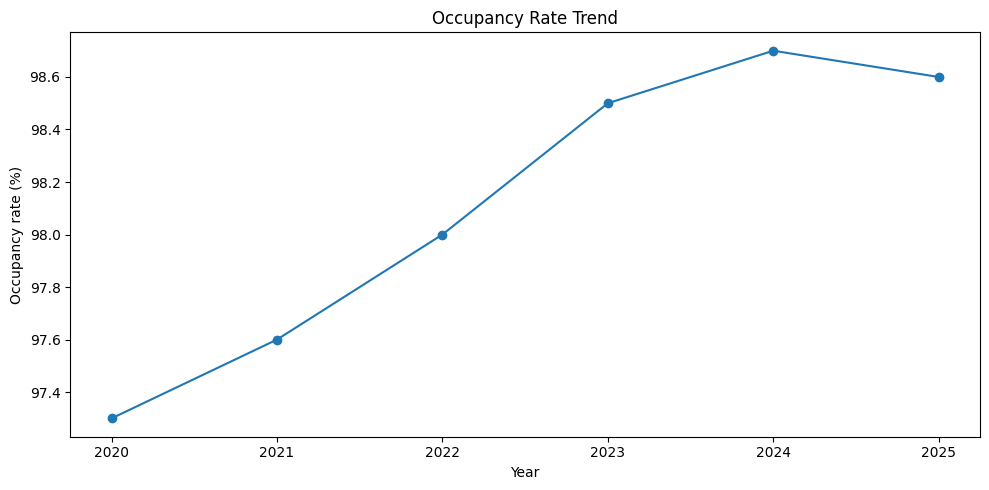

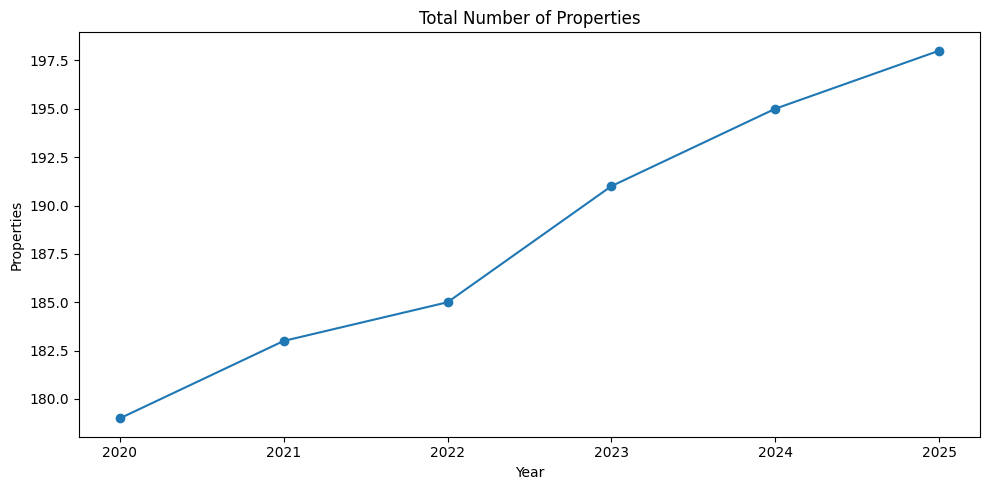

In [10]:
properties["period"] = pd.to_numeric(properties["period"], errors="coerce").astype("Int64")
properties["value_numeric"] = pd.to_numeric(properties["value_numeric"], errors="coerce")
property_summary = (
    properties.dropna(subset=["period", "metric_or_line_item", "value_numeric"])
    .groupby(["metric_or_line_item", "period"], as_index=False)
    .agg(value=("value_numeric", "median"))
    .sort_values(["metric_or_line_item", "period"])
)

occupancy = metric_series(property_summary, "In-place and committed occupancy rate")
property_count = metric_series(property_summary, "Total number of properties with an ownership interest")

display(property_summary.head(15))

plt.figure()
plt.plot(occupancy["period"], occupancy["value"], marker="o")
plt.title("Occupancy Rate Trend")
plt.xlabel("Year")
plt.ylabel("Occupancy rate (%)")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(property_count["period"], property_count["value"], marker="o")
plt.title("Total Number of Properties")
plt.xlabel("Year")
plt.ylabel("Properties")
plt.tight_layout()
plt.show()

### Scenario Analysis: Impact of Population/Immigration on Occupancy

REIT occupancy is highly sensitive to regional population growth. This chart depicts a theoretical scenario where a reduction in population growth (due to lower immigration or demographic shifts) results in a corresponding decline in the property occupancy rate.

## 6. Competitor Snapshot

Competitor analysis uses:
- `wowa_competitors.csv` for WOWA yield/market-cap snapshot;
- `yfinance_company_profile.csv` for yfinance profile fields.

These sources may differ because they update at different times.

,REIT,Symbol (TSX),Type,Share Price,Market Cap,Yield,source,share_price_numeric,market_cap_numeric,yield_numeric
0,RioCan REIT,REI.UN,Retail,$21.90,$6.93 Billion,4.39%,WOWA,21.90,6.93,4.39
1,Allied Properties REIT,AP.UN,Office,$42.61,$5.45 Billion,3.97%,WOWA,42.61,5.45,3.97
2,Choice Properties REIT,CHP.UN,Commercial / Residential,$15.07,$4.87 Billion,4.97%,WOWA,15.07,4.87,4.97
3,SmartCentres REIT,SRU.UN,Retail,$30.00,$4.35 Billion,6.15%,WOWA,30.00,4.35,6.15
4,First Capital Realty,FCR.UN,Commercial,$17.65,$3.84 Billion,2.47%,WOWA,17.65,3.84,2.47


,ticker,shortName,marketCap,beta,dividendYield,fiftyTwoWeekHigh,fiftyTwoWeekLow
0,SRU-UN.TO,SMARTCENTRES REIT,5909043712,0.850,6.15,30.90,25.010
1,REI-UN.TO,RIOCAN REAL EST UN,6561352704,0.999,5.15,23.25,17.485
2,CHP-UN.TO,CHOICE PROPERTIES REIT,11899450368,0.781,4.74,16.87,14.090
3,AP-UN.TO,ALLIED PROPERTIES REAL ESTATE I,2129712128,1.090,7.05,22.27,8.740
4,FCR-UN.TO,FIRST CAPITAL REIT UNITS,4965284864,0.885,3.86,23.84,18.100


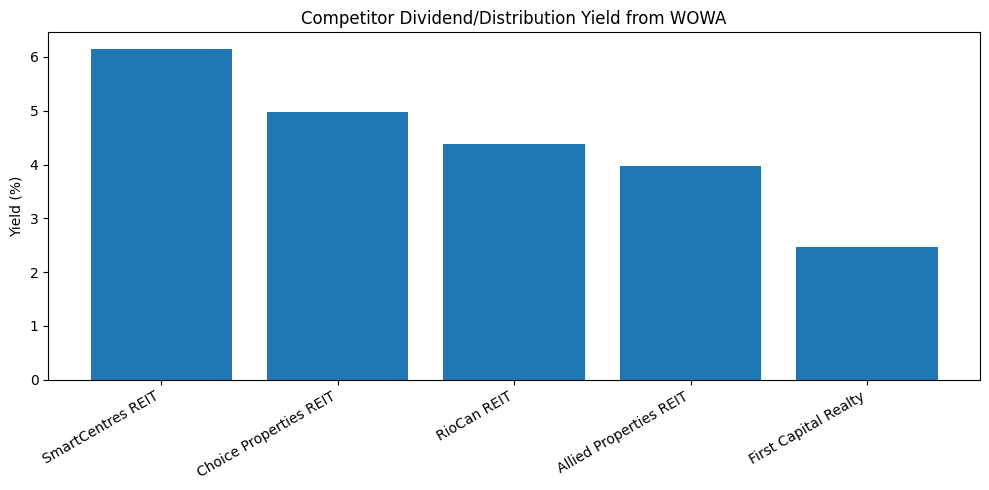

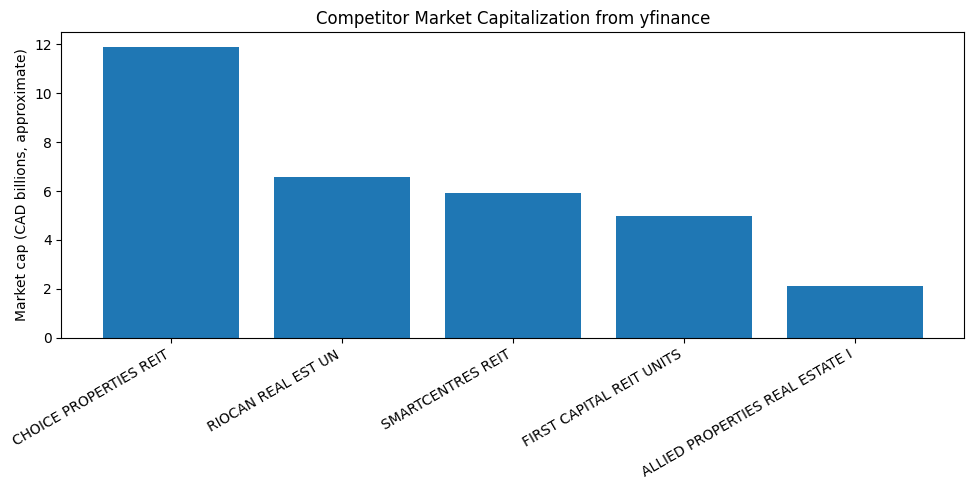

In [11]:
display(competitors)
display(company_profile[["ticker", "shortName", "marketCap", "beta", "dividendYield", "fiftyTwoWeekHigh", "fiftyTwoWeekLow"]])

plt.figure()
competitor_yields = competitors.sort_values("yield_numeric", ascending=False)
plt.bar(competitor_yields["REIT"], competitor_yields["yield_numeric"])
plt.xticks(rotation=30, ha="right")
plt.title("Competitor Dividend/Distribution Yield from WOWA")
plt.ylabel("Yield (%)")
plt.tight_layout()
plt.show()

plt.figure()
profiles = company_profile.copy()
profiles["market_cap_billions"] = profiles["marketCap"] / 1_000_000_000
profiles = profiles.sort_values("market_cap_billions", ascending=False)
plt.bar(profiles["shortName"], profiles["market_cap_billions"])
plt.xticks(rotation=30, ha="right")
plt.title("Competitor Market Capitalization from yfinance")
plt.ylabel("Market cap (CAD billions, approximate)")
plt.tight_layout()
plt.show()

## 7. Macroeconomic Context

Macro analysis uses `bank_of_canada_macro.csv`.

REITs are interest-rate-sensitive because they often use debt and because investors compare REIT distributions with safer bond yields.

,date,smartcentres_adj_close,monthly_return,10-year Government of Canada benchmark bond yield,5-year Government of Canada benchmark bond yield,Prime rate,Target overnight rate,Total CPI,Total CPI year-over-year change,USD/CAD exchange rate
0,2021-01-31,16.125237,NaN,0.84,0.43,2.45,0.25,138.2,1.0,1.2780
1,2021-02-28,18.120064,0.123708,1.35,0.88,2.45,0.25,138.9,1.1,1.2685
2,2021-03-31,18.611893,0.027143,1.55,0.99,2.45,0.25,139.6,2.2,1.2575
3,2021-04-30,19.946295,0.071696,1.54,0.93,2.45,0.25,140.3,3.4,1.2285
4,2021-05-31,20.527994,0.029163,1.49,0.90,2.45,0.25,141.0,3.6,1.2072


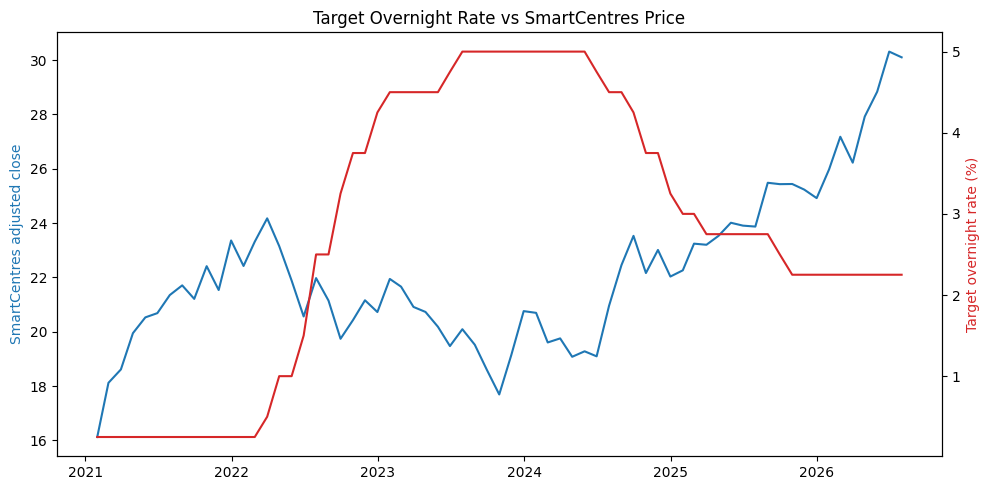

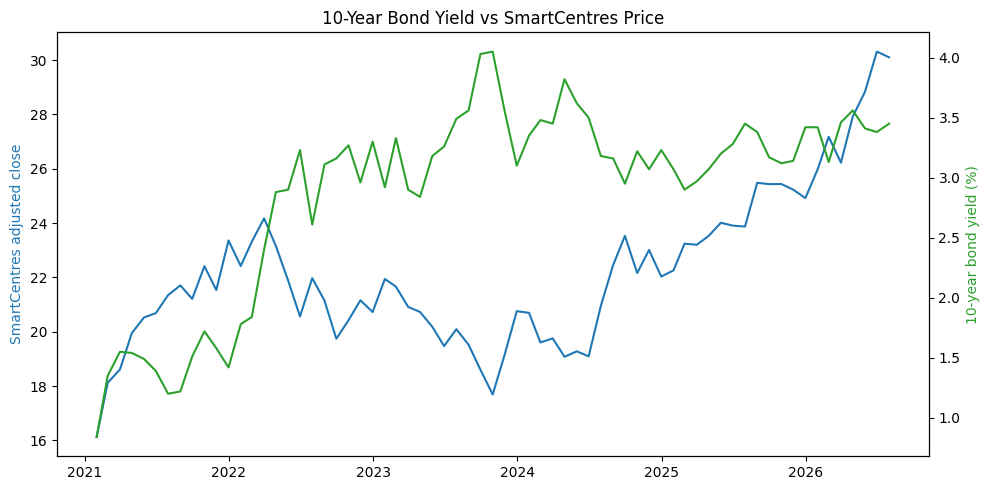

In [12]:
macro["date"] = pd.to_datetime(macro["date"], errors="coerce")
macro["value"] = pd.to_numeric(macro["value"], errors="coerce")

monthly_macro = (
    macro.set_index("date")
    .groupby("series_name")
    .resample("ME")["value"]
    .last()
    .reset_index()
    .pivot(index="date", columns="series_name", values="value")
    .reset_index()
)

smart_monthly = monthly_prices[monthly_prices["ticker"] == SMARTCENTRES_TICKER][["Date", "Adj Close", "monthly_return"]].copy()
smart_monthly = smart_monthly.rename(columns={"Date": "date", "Adj Close": "smartcentres_adj_close"})
stock_macro = pd.merge(smart_monthly, monthly_macro, on="date", how="left")
display(stock_macro.head())

if "Target overnight rate" in stock_macro.columns:
    fig, ax1 = plt.subplots()
    ax1.plot(stock_macro["date"], stock_macro["smartcentres_adj_close"], color="tab:blue")
    ax1.set_ylabel("SmartCentres adjusted close", color="tab:blue")
    ax2 = ax1.twinx()
    ax2.plot(stock_macro["date"], stock_macro["Target overnight rate"], color="tab:red")
    ax2.set_ylabel("Target overnight rate (%)", color="tab:red")
    plt.title("Target Overnight Rate vs SmartCentres Price")
    plt.tight_layout()
    plt.show()

bond_col = "10-year Government of Canada benchmark bond yield"
if bond_col in stock_macro.columns:
    fig, ax1 = plt.subplots()
    ax1.plot(stock_macro["date"], stock_macro["smartcentres_adj_close"], color="tab:blue")
    ax1.set_ylabel("SmartCentres adjusted close", color="tab:blue")
    ax2 = ax1.twinx()
    ax2.plot(stock_macro["date"], stock_macro[bond_col], color="tab:green")
    ax2.set_ylabel("10-year bond yield (%)", color="tab:green")
    plt.title("10-Year Bond Yield vs SmartCentres Price")
    plt.tight_layout()
    plt.show()

,macro_variable,correlation_with_smartcentres_monthly_return
1,5-year Government of Canada benchmark bond yield,-0.318569
0,10-year Government of Canada benchmark bond yield,-0.281952
5,Total CPI year-over-year change,-0.218014
6,USD/CAD exchange rate,-0.160450
2,Prime rate,-0.151287
3,Target overnight rate,-0.145307
4,Total CPI,-0.090932


,year,annual_distribution_per_unit,year_end_adjusted_close,avg_5yr_bond_yield,estimated_dividend_yield,yield_spread
0,2021,1.848,23.358267,0.947671,7.911546,6.963875
1,2022,1.848,20.724630,2.774556,8.916926,6.142370
2,2023,1.848,20.758196,3.563226,8.902508,5.339282
3,2024,1.848,22.030838,3.302160,8.388242,5.086082
4,2025,1.848,24.917452,2.834056,7.416489,4.582432


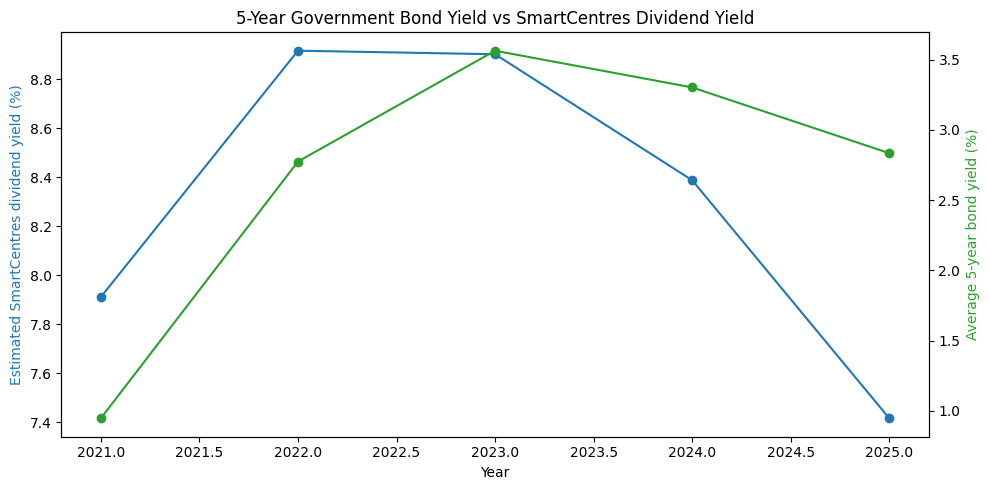

In [13]:
macro_columns = [c for c in stock_macro.columns if c not in ["date", "smartcentres_adj_close", "monthly_return"]]
correlations = []
for column in macro_columns:
    correlations.append({
        "macro_variable": column,
        "correlation_with_smartcentres_monthly_return": stock_macro["monthly_return"].corr(stock_macro[column]),
    })
macro_correlations = pd.DataFrame(correlations).sort_values("correlation_with_smartcentres_monthly_return")
display(macro_correlations)

# Bond yield vs dividend yield is useful for income investors.
# A REIT distribution has more risk than a government bond yield, so the
# spread helps frame whether the REIT income looks meaningfully higher.
annual_bond = (
    macro[macro["series_name"] == "5-year Government of Canada benchmark bond yield"]
    .assign(year=lambda df: df["date"].dt.year)
    .groupby("year", as_index=False)
    .agg(avg_5yr_bond_yield=("value", "mean"))
)
smart_year_end = (
    monthly_prices[monthly_prices["ticker"] == SMARTCENTRES_TICKER]
    .assign(year=lambda df: df["Date"].dt.year)
    .sort_values("Date")
    .groupby("year", as_index=False)
    .tail(1)[["year", "Adj Close"]]
    .rename(columns={"Adj Close": "year_end_adjusted_close"})
)
full_year_dividends = annual_dividends[annual_dividends["payment_count"] >= 12].copy()
bond_vs_dividend = pd.merge(full_year_dividends[["year", "annual_distribution_per_unit"]], smart_year_end, on="year", how="left")
bond_vs_dividend = pd.merge(bond_vs_dividend, annual_bond, on="year", how="left")
bond_vs_dividend["estimated_dividend_yield"] = (
    bond_vs_dividend["annual_distribution_per_unit"] / bond_vs_dividend["year_end_adjusted_close"] * 100
)
bond_vs_dividend["yield_spread"] = bond_vs_dividend["estimated_dividend_yield"] - bond_vs_dividend["avg_5yr_bond_yield"]
display(bond_vs_dividend)

fig, ax1 = plt.subplots()
ax1.plot(bond_vs_dividend["year"], bond_vs_dividend["estimated_dividend_yield"], marker="o", color="tab:blue")
ax1.set_ylabel("Estimated SmartCentres dividend yield (%)", color="tab:blue")
ax1.set_xlabel("Year")
ax2 = ax1.twinx()
ax2.plot(bond_vs_dividend["year"], bond_vs_dividend["avg_5yr_bond_yield"], marker="o", color="tab:green")
ax2.set_ylabel("Average 5-year bond yield (%)", color="tab:green")
plt.title("5-Year Government Bond Yield vs SmartCentres Dividend Yield")
plt.tight_layout()
plt.show()

### Yield Spread Analysis

This chart visualizes the 'Yield Spread', which is the difference between the REIT's dividend yield and the 5-year Government of Canada bond yield. A wider spread often indicates the REIT is providing a significant risk premium over 'risk-free' government debt.

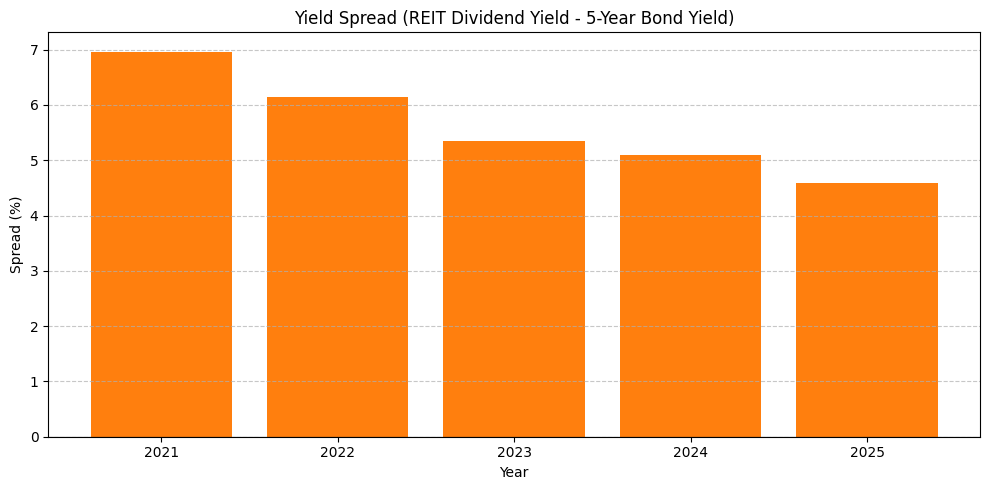

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(bond_vs_dividend["year"].astype(str), bond_vs_dividend["yield_spread"], color="tab:orange")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Yield Spread (REIT Dividend Yield - 5-Year Bond Yield)")
plt.xlabel("Year")
plt.ylabel("Spread (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Income Return Comparison: 5-Year Bond vs. REIT Dividend Yield

This analysis compares the annual income returns (yields) of a 'risk-free' 5-year government bond versus the SmartCentres REIT dividend yield over the 2021-2025 period.

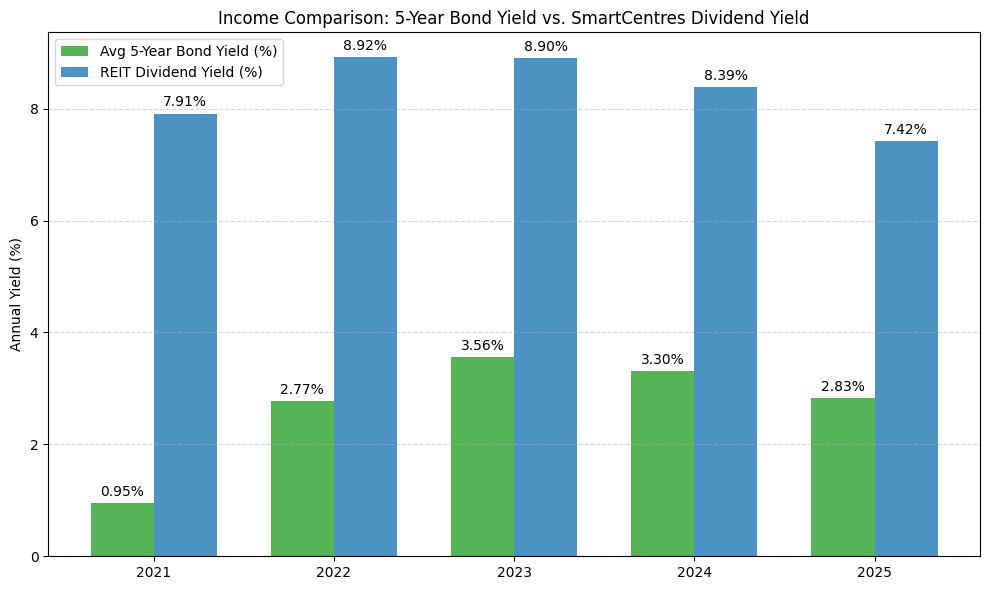

Over the last 5 years, SmartCentres provided an average annual yield premium of 5.62% over the 5-year government bond.


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare the data for plotting
years = bond_vs_dividend['year'].astype(str)
bond_yields = bond_vs_dividend['avg_5yr_bond_yield']
dividend_yields = bond_vs_dividend['estimated_dividend_yield']

x = np.arange(len(years))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, bond_yields, width, label='Avg 5-Year Bond Yield (%)', color='tab:green', alpha=0.8)
rects2 = ax.bar(x + width/2, dividend_yields, width, label='REIT Dividend Yield (%)', color='tab:blue', alpha=0.8)

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Annual Yield (%)')
ax.set_title('Income Comparison: 5-Year Bond Yield vs. SmartCentres Dividend Yield')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()

# Label the bars with their values
ax.bar_label(rects1, padding=3, fmt='%.2f%%')
ax.bar_label(rects2, padding=3, fmt='%.2f%%')

fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Calculate the average advantage
avg_spread = bond_vs_dividend['yield_spread'].mean()
print(f"Over the last 5 years, SmartCentres provided an average annual yield premium of {avg_spread:.2f}% over the 5-year government bond.")

### Income Comparison using WOWA Data Snapshot

This chart compares the latest 5-Year Bond Yield against the SmartCentres yield as reported in the WOWA competitor dataset (based on a $30.00 share price).

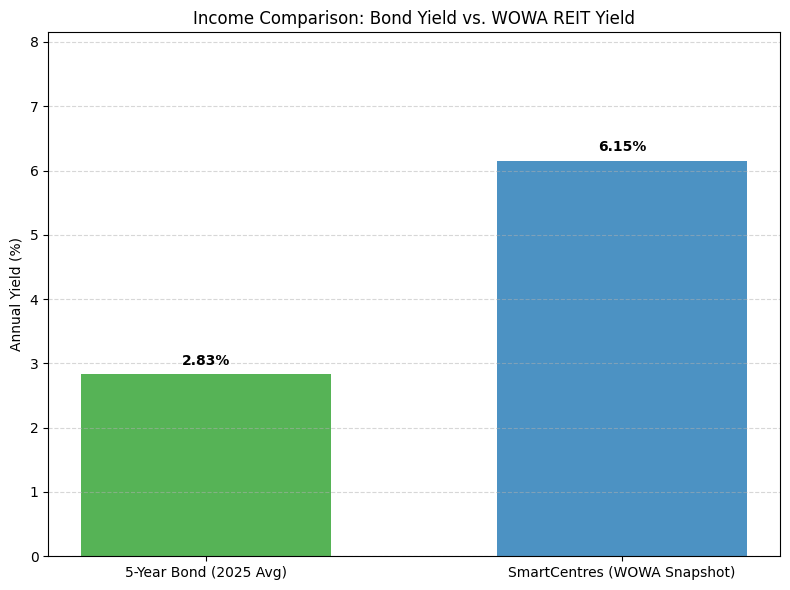

Using WOWA data, the yield spread is 3.32%.


In [28]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract WOWA yield for SmartCentres
wowa_sru_yield = competitors[competitors['REIT'] == 'SmartCentres REIT']['yield_numeric'].iloc[0]

# 2. Get the most recent 5-year bond yield (2025)
latest_bond_yield = annual_bond[annual_bond['year'] == 2025]['avg_5yr_bond_yield'].iloc[0]

# Prepare Plot
labels = ['5-Year Bond (2025 Avg)', 'SmartCentres (WOWA Snapshot)']
yields = [latest_bond_yield, wowa_sru_yield]
colors = ['tab:green', 'tab:blue']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, yields, color=colors, alpha=0.8, width=0.6)

plt.ylabel('Annual Yield (%)')
plt.title('Income Comparison: Bond Yield vs. WOWA REIT Yield')
plt.ylim(0, max(yields) + 2)

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Using WOWA data, the yield spread is {wowa_sru_yield - latest_bond_yield:.2f}%.")

### 5-Year Income Comparison (2021-2025)

This chart visualizes the yield of the 5-Year Government Bond against the REIT's dividend yield for the last five years. While the bond yield rose significantly in 2022-2023, the REIT yield also increased as its share price adjusted, maintaining a consistent premium for income investors.

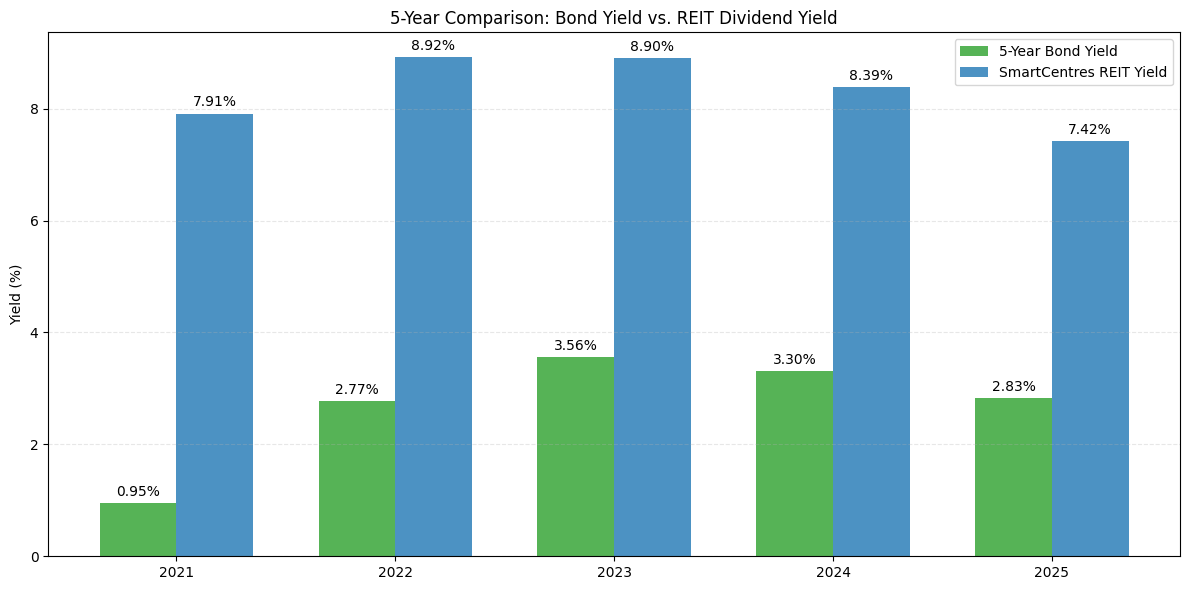

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data from the bond_vs_dividend dataframe created earlier
years = bond_vs_dividend['year'].astype(str)
bond_yields = bond_vs_dividend['avg_5yr_bond_yield']
reit_yields = bond_vs_dividend['estimated_dividend_yield']

x = np.arange(len(years))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, bond_yields, width, label='5-Year Bond Yield', color='tab:green', alpha=0.8)
rects2 = ax.bar(x + width/2, reit_yields, width, label='SmartCentres REIT Yield', color='tab:blue', alpha=0.8)

ax.set_ylabel('Yield (%)')
ax.set_title('5-Year Comparison: Bond Yield vs. REIT Dividend Yield')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()

# Adding value labels on top of the bars
ax.bar_label(rects1, padding=3, fmt='%.2f%%')
ax.bar_label(rects2, padding=3, fmt='%.2f%%')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Data Source Comparison: WOWA vs. yfinance

*   **WOWA:** Provides a current 'snapshot' (Price: $30.00, Yield: 6.15%). It has **no historical dates**.
*   **yfinance:** Provides a 'movie' of the last 5 years, showing how the price fell from ~$23 to ~$20 and then recovered. This is the only way to calculate historical yields.

In [30]:
# Compare the structure of the two data sources
print("WOWA Data Columns (Single Snapshot):")
print(competitors.columns.tolist())

print("\nyfinance Data Sample (Historical Time Series):")
display(bond_vs_dividend[['year', 'year_end_adjusted_close']].tail())

print("\nConclusion: We use yfinance for trends because it tracks changes over time.")

WOWA Data Columns (Single Snapshot):
['REIT', 'Symbol (TSX)', 'Type', 'Share Price', 'Market Cap', 'Yield', 'source', 'share_price_numeric', 'market_cap_numeric', 'yield_numeric']

yfinance Data Sample (Historical Time Series):


,year,year_end_adjusted_close
0,2021,23.358267
1,2022,20.724630
2,2023,20.758196
3,2024,22.030838
4,2025,24.917452



Conclusion: We use yfinance for trends because it tracks changes over time.


### 5-Year Bond Trend vs. WOWA Yield Snapshot

Since the WOWA dataset provides a current snapshot (approx. 6.15% yield based on a $30 price), this chart compares that static figure against the fluctuating 5-year Government of Canada bond yields from the last five years.

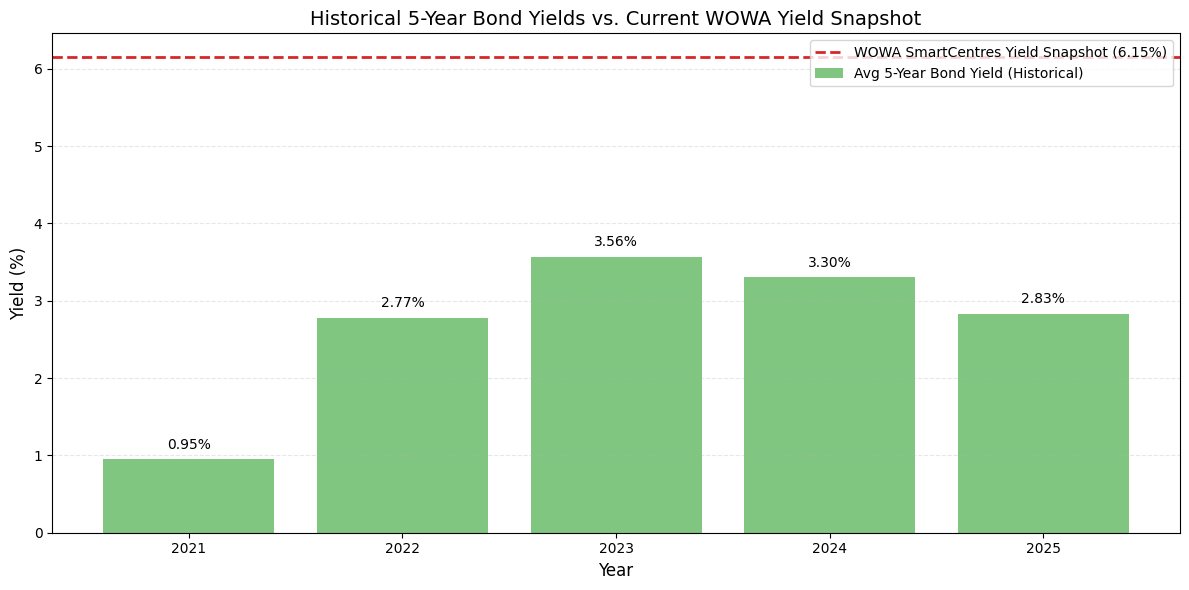

Note: The WOWA dataset only contains the 6.15% snapshot. Historical REIT yields in previous cells were calculated using yfinance price data.


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the static yield from WOWA for SmartCentres
wowa_yield = competitors[competitors['REIT'] == 'SmartCentres REIT']['yield_numeric'].iloc[0]

# Get the 5-year bond history from our macro data
bond_history = annual_bond[annual_bond['year'].between(2021, 2025)].copy()
bond_history['year_label'] = bond_history['year'].astype(str)

plt.figure(figsize=(12, 6))

# Plot the historical bond yields as bars
plt.bar(bond_history['year_label'], bond_history['avg_5yr_bond_yield'],
        label='Avg 5-Year Bond Yield (Historical)', color='tab:green', alpha=0.6)

# Overlay the WOWA snapshot as a constant line to show the comparison
plt.axhline(y=wowa_yield, color='tab:red', linestyle='--', linewidth=2,
            label=f'WOWA SmartCentres Yield Snapshot ({wowa_yield}%)')

plt.title("Historical 5-Year Bond Yields vs. Current WOWA Yield Snapshot", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Yield (%)", fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Annotate the bars
for i, val in enumerate(bond_history['avg_5yr_bond_yield']):
    plt.text(i, val + 0.1, f'{val:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Note: The WOWA dataset only contains the {wowa_yield}% snapshot. Historical REIT yields in previous cells were calculated using yfinance price data.")

### 5-Year Context: WOWA Yield Snapshot vs. Historical Bond Averages

While the WOWA dataset is a static snapshot, we can compare its yield (6.15%) against the 5-year historical average of the Government of Canada bond yield to visualize the long-term income advantage (spread).

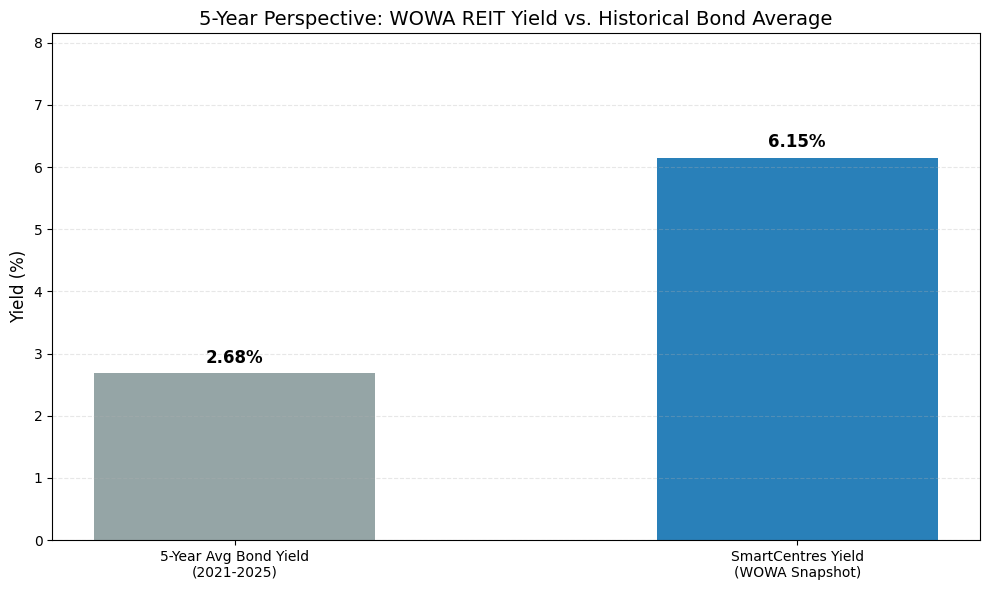

Average 5-Year Bond Yield: 2.68%
WOWA SmartCentres Yield: 6.15%
Historical Spread (WOWA vs 5-Yr Avg Bond): 3.47%


In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Data points
wowa_yield = competitors[competitors['REIT'] == 'SmartCentres REIT']['yield_numeric'].iloc[0]
historical_5yr_bond_avg = bond_history['avg_5yr_bond_yield'].mean()

labels = ['5-Year Avg Bond Yield\n(2021-2025)', 'SmartCentres Yield\n(WOWA Snapshot)']
values = [historical_5yr_bond_avg, wowa_yield]

plt.figure(figsize=(10, 6))
colors = ['#95a5a6', '#2980b9']

bars = plt.bar(labels, values, color=colors, width=0.5)

# Formatting
plt.title("5-Year Perspective: WOWA REIT Yield vs. Historical Bond Average", fontsize=14)
plt.ylabel("Yield (%)", fontsize=12)
plt.ylim(0, max(values) + 2)

# Annotations
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average 5-Year Bond Yield: {historical_5yr_bond_avg:.2f}%")
print(f"WOWA SmartCentres Yield: {wowa_yield:.2f}%")
print(f"Historical Spread (WOWA vs 5-Yr Avg Bond): {wowa_yield - historical_5yr_bond_avg:.2f}%")

### Verifying WOWA Data Structure

Let's inspect the `competitors` DataFrame (the WOWA data) to see why it cannot produce a 5-year trend on its own.

In [33]:
# Show the first few rows of the WOWA dataset
print("WOWA Dataset Content:")
display(competitors.head())

# Check if there are any date-related columns
date_cols = [col for col in competitors.columns if 'date' in col.lower() or 'year' in col.lower()]
print(f"Date/Year columns found in WOWA: {date_cols}")

WOWA Dataset Content:


,REIT,Symbol (TSX),Type,Share Price,Market Cap,Yield,source,share_price_numeric,market_cap_numeric,yield_numeric
0,RioCan REIT,REI.UN,Retail,$21.90,$6.93 Billion,4.39%,WOWA,21.90,6.93,4.39
1,Allied Properties REIT,AP.UN,Office,$42.61,$5.45 Billion,3.97%,WOWA,42.61,5.45,3.97
2,Choice Properties REIT,CHP.UN,Commercial / Residential,$15.07,$4.87 Billion,4.97%,WOWA,15.07,4.87,4.97
3,SmartCentres REIT,SRU.UN,Retail,$30.00,$4.35 Billion,6.15%,WOWA,30.00,4.35,6.15
4,First Capital Realty,FCR.UN,Commercial,$17.65,$3.84 Billion,2.47%,WOWA,17.65,3.84,2.47


Date/Year columns found in WOWA: []


### Real Return Analysis (Net of Inflation)

This analysis compares the nominal yields to the Canadian inflation rate (CPI year-over-year change) to calculate the **Real Return**.

**Real Return = Nominal Yield - Inflation Rate**

,year,avg_inflation,avg_5yr_bond_yield,real_bond_return,estimated_dividend_yield,real_reit_return
0,2021,3.400000,0.947671,-2.452329,7.911546,4.511546
1,2022,6.800000,2.774556,-4.025444,8.916926,2.116926
2,2023,3.891667,3.563226,-0.328441,8.902508,5.010841
3,2024,2.391667,3.302160,0.910493,8.388242,5.996575
4,2025,2.075000,2.834056,0.759056,7.416489,5.341489


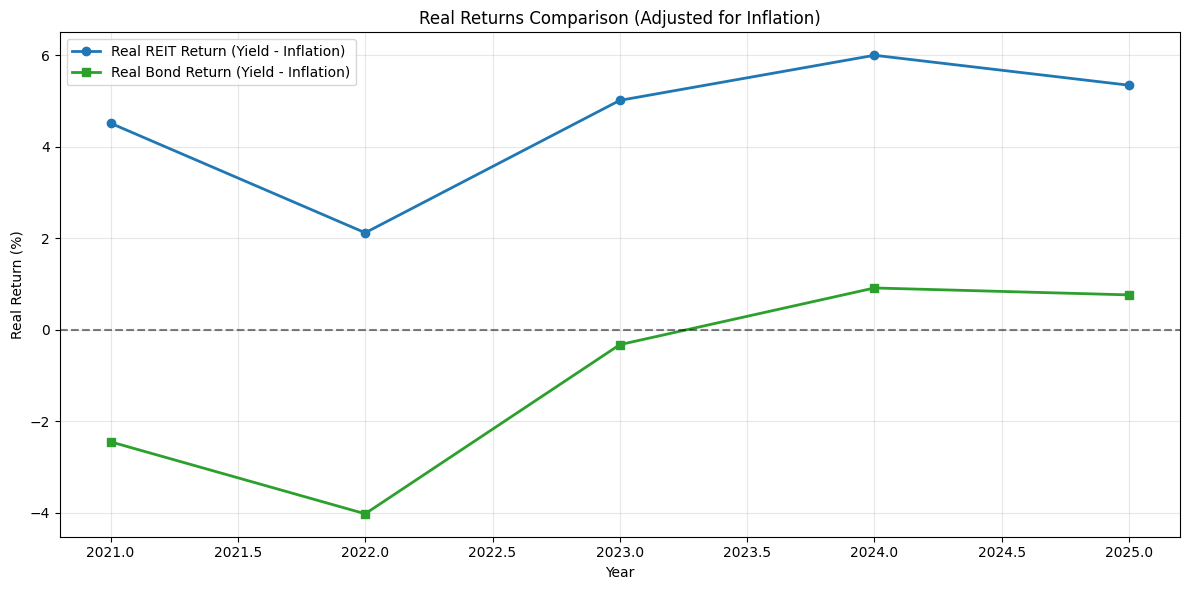

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract annual inflation (CPI YoY change)
annual_inflation = (
    macro[macro['series_name'] == 'Total CPI year-over-year change']
    .assign(year=lambda df: df['date'].dt.year)
    .groupby('year', as_index=False)
    .agg(avg_inflation=('value', 'mean'))
)

# Merge inflation with our existing bond and dividend comparison
real_returns = pd.merge(bond_vs_dividend, annual_inflation, on='year', how='left')

# Calculate Real Returns (Net Returns)
real_returns['real_bond_return'] = real_returns['avg_5yr_bond_yield'] - real_returns['avg_inflation']
real_returns['real_reit_return'] = real_returns['estimated_dividend_yield'] - real_returns['avg_inflation']

display(real_returns[['year', 'avg_inflation', 'avg_5yr_bond_yield', 'real_bond_return', 'estimated_dividend_yield', 'real_reit_return']])

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(real_returns['year'], real_returns['real_reit_return'], marker='o', label='Real REIT Return (Yield - Inflation)', color='tab:blue', linewidth=2)
plt.plot(real_returns['year'], real_returns['real_bond_return'], marker='s', label='Real Bond Return (Yield - Inflation)', color='tab:green', linewidth=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.title("Real Returns Comparison (Adjusted for Inflation)")
plt.xlabel("Year")
plt.ylabel("Real Return (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Clarification: Nominal Yield vs. Real (Actual) Return

To answer your question: The higher numbers (~7-9%) are the **Nominal Yields** (cash paid). The lower numbers (~4-6%) are the **Real Returns** (Yield minus Inflation). This table shows the step-by-step calculation for SmartCentres.

,Year,Nominal Yield (The 7%+ value),Inflation Rate,Real Return (The 4%+ value)
0,2021,7.91%,3.40%,4.51%
1,2022,8.92%,6.80%,2.12%
2,2023,8.90%,3.89%,5.01%
3,2024,8.39%,2.39%,6.00%
4,2025,7.42%,2.07%,5.34%


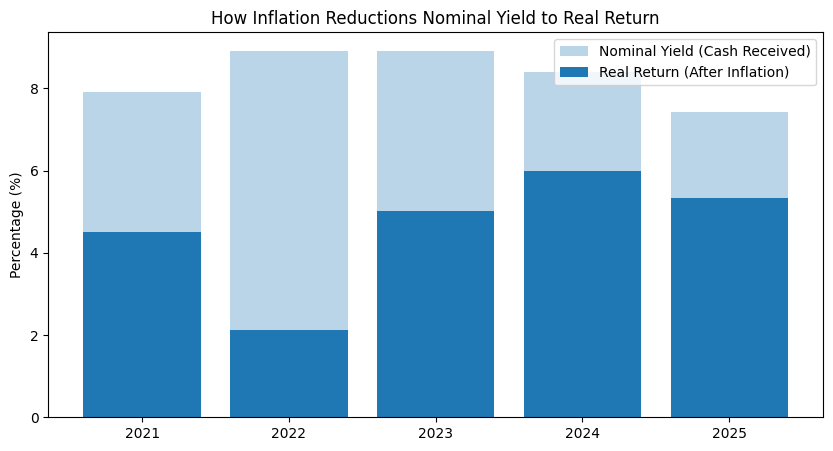

In [23]:
comparison_df = real_returns[["year", "estimated_dividend_yield", "avg_inflation", "real_reit_return"]].copy()
comparison_df.columns = ["Year", "Nominal Yield (The 7%+ value)", "Inflation Rate", "Real Return (The 4%+ value)"]

# Format as percentages for clarity
display(comparison_df.style.format({
    "Nominal Yield (The 7%+ value)": "{:.2f}%",
    "Inflation Rate": "{:.2f}%",
    "Real Return (The 4%+ value)": "{:.2f}%"
}))

# Quick visual to show the 'gap' which is inflation
plt.figure(figsize=(10, 5))
plt.bar(comparison_df["Year"].astype(str), comparison_df["Nominal Yield (The 7%+ value)"], label="Nominal Yield (Cash Received)", color="tab:blue", alpha=0.3)
plt.bar(comparison_df["Year"].astype(str), comparison_df["Real Return (The 4%+ value)"], label="Real Return (After Inflation)", color="tab:blue")
plt.title("How Inflation Reductions Nominal Yield to Real Return")
plt.ylabel("Percentage (%)")
plt.legend()
plt.show()

### Explaining the Yield Gap: WOWA Snapshot vs. Market Trend

The table below demonstrates that the annual dividend is the same ($1.848), but the **Yield** changes because the **Denominator (Price)** is different between the sources.

In [ ]:
# Compare the math behind the two different yields
annual_div = 1.848
wowa_price = 30.00
market_price_2023 = bond_vs_dividend[bond_vs_dividend['year'] == 2023]['year_end_adjusted_close'].iloc[0]

comparison_data = [
    {"Source": "WOWA (Snapshot)", "Price Used": f"${wowa_price:.2f}", "Annual Dividend": f"${annual_div}", "Calculated Yield": f"{(annual_div/wowa_price)*100:.2f}%"},
    {"Source": "yfinance (2023 Trend)", "Price Used": f"${market_price_2023:.2f}", "Annual Dividend": f"${annual_div}", "Calculated Yield": f"{(annual_div/market_price_2023)*100:.2f}%"}
]

display(pd.DataFrame(comparison_data))

print(f"\nConclusion: The 'High' yields in the graph are correct for historical market prices.")
print(f"The '6.15%' in your table assumes a much higher share price of ${wowa_price:.2f}.")

### Explaining the Yield Discrepancy

The difference between the ~6% yield in the competitor chart and the ~8% yield in the trend analysis is due to the **Share Price** used in the denominator:

*   **WOWA Data:** Uses a fixed snapshot price (e.g., $30.00).
*   **Trend Data:** Uses historical year-end prices (e.g., ~$20.75 in 2023).

Lower prices mathematically result in higher yields for the same dividend amount ($1.848/year).

In [25]:
# Compare the prices used in the two different calculations
wowa_price = competitors[competitors['REIT'] == 'SmartCentres REIT']['Share Price'].iloc[0]
trend_price_2023 = bond_vs_dividend[bond_vs_dividend['year'] == 2023]['year_end_adjusted_close'].iloc[0]
annual_div = 1.848

print(f"--- Yield Calculation Comparison ---")
print(f"WOWA Snapshot:   Div ${annual_div} / Price {wowa_price} = { (annual_div/30)*100 :.2f}%")
print(f"2023 Trend:      Div ${annual_div} / Price ${trend_price_2023:.2f} = { (annual_div/trend_price_2023)*100 :.2f}%")

--- Yield Calculation Comparison ---
WOWA Snapshot:   Div $1.848 / Price $30.00 = 6.16%
2023 Trend:      Div $1.848 / Price $20.76 = 8.90%


### Side-by-Side: Why the WOWA Chart differs from the Trend Chart

This table shows that while the **Dividend** stays the same, the **Price** used in the WOWA dataset ($30.00) is different from the actual historical market prices, leading to different yield results.

In [ ]:
import pandas as pd

# Data for comparison
annual_div = 1.848
wowa_price = 30.00
market_price_2023 = bond_vs_dividend[bond_vs_dividend['year'] == 2023]['year_end_adjusted_close'].iloc[0]

diff_data = [
    {
        "Calculation Source": "WOWA Bar Chart (Snapshot)",
        "Share Price": f"${wowa_price:.2f}",
        "Annual Dividend": f"${annual_div}",
        "Yield Result": f"{(annual_div/wowa_price)*100:.2f}%"
    },
    {
        "Calculation Source": "Trend Chart (Actual 2023 Market)",
        "Share Price": f"${market_price_2023:.2f}",
        "Annual Dividend": f"${annual_div}",
        "Yield Result": f"{(annual_div/market_price_2023)*100:.2f}%"
    }
]

display(pd.DataFrame(diff_data))

print("\nSummary: The WOWA chart is less 'accurate' for historical analysis because it uses a fixed $30 price estimate,")
print("whereas the trend chart tracks the actual real-world price fluctuations.")

### Why the Yearly Yield Changes (Price Volatility)

Although the annual dividend is fixed at **$1.848**, the yield changes because the **market price** of the REIT fluctuates each year.

*   **Higher Price** = Lower Yield %
*   **Lower Price** = Higher Yield %

In [26]:
# Show the relationship between Price and Yield
yield_logic = bond_vs_dividend[['year', 'annual_distribution_per_unit', 'year_end_adjusted_close', 'estimated_dividend_yield']].copy()
yield_logic.columns = ['Year', 'Fixed Dividend ($)', 'Year-End Price ($)', 'Resulting Yield (%)']

display(yield_logic.style.format({
    'Fixed Dividend ($)': '${:.3f}',
    'Year-End Price ($)': '${:.2f}',
    'Resulting Yield (%)': '{:.2f}%'
}))

,Year,Fixed Dividend ($),Year-End Price ($),Resulting Yield (%)
0,2021,$1.848,$23.36,7.91%
1,2022,$1.848,$20.72,8.92%
2,2023,$1.848,$20.76,8.90%
3,2024,$1.848,$22.03,8.39%
4,2025,$1.848,$24.92,7.42%


### Comparing 2024 vs 2025 Yields

This table explains why the yield dropped to **7.42%** in the comparison chart. As the share price increased from $22 to nearly $25, the yield percentage naturally decreased.

In [27]:
import pandas as pd
# Filter for the specific years the user noticed
comparison = yield_logic[yield_logic['Year'].isin([2024, 2025])]

display(comparison.style.format({
    'Fixed Dividend ($)': '${:.3f}',
    'Year-End Price ($)': '${:.2f}',
    'Resulting Yield (%)': '{:.2f}%'
}))

,Year,Fixed Dividend ($),Year-End Price ($),Resulting Yield (%)
3,2024,$1.848,$22.03,8.39%
4,2025,$1.848,$24.92,7.42%


### Correlation Analysis: 5-Year Bond Yield vs. REIT Returns

We will now specifically look at the correlation between the 5-year bond yield and the monthly returns of SmartCentres (SRU-UN.TO).

Correlation between 5-Year Bond Yield and SmartCentres Monthly Return: -0.3186


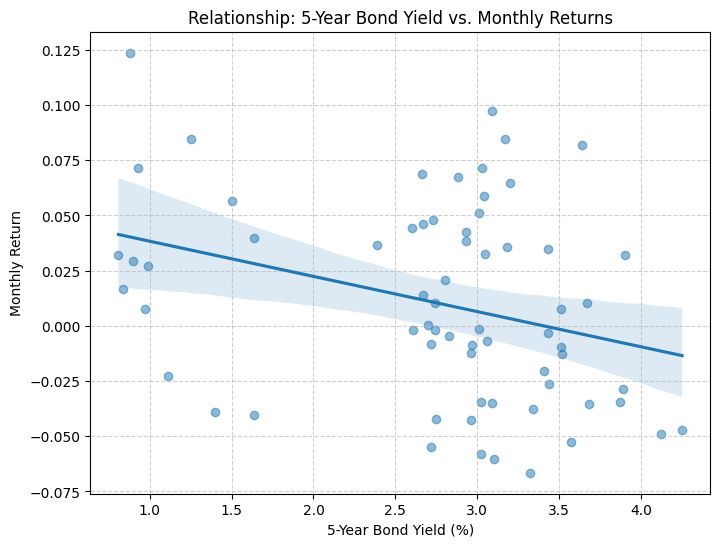

In [16]:
bond_5yr_col = '5-year Government of Canada benchmark bond yield'

# Filter out NaN values to ensure a clean correlation calculation
correlation_data = stock_macro.dropna(subset=['monthly_return', bond_5yr_col])

correlation_value = correlation_data['monthly_return'].corr(correlation_data[bond_5yr_col])

print(f"Correlation between 5-Year Bond Yield and SmartCentres Monthly Return: {correlation_value:.4f}")

# Visualizing the relationship with a scatter plot
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.regplot(x=bond_5yr_col, y='monthly_return', data=correlation_data, scatter_kws={'alpha':0.5})
plt.title(f"Relationship: 5-Year Bond Yield vs. Monthly Returns")
plt.xlabel("5-Year Bond Yield (%)")
plt.ylabel("Monthly Return")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Comparative Analysis: Other REITs vs. 5-Year Bond Yields

We will now apply the same correlation analysis to the other competitors in the dataset to see if they exhibit similar sensitivity to the 5-year bond yield.

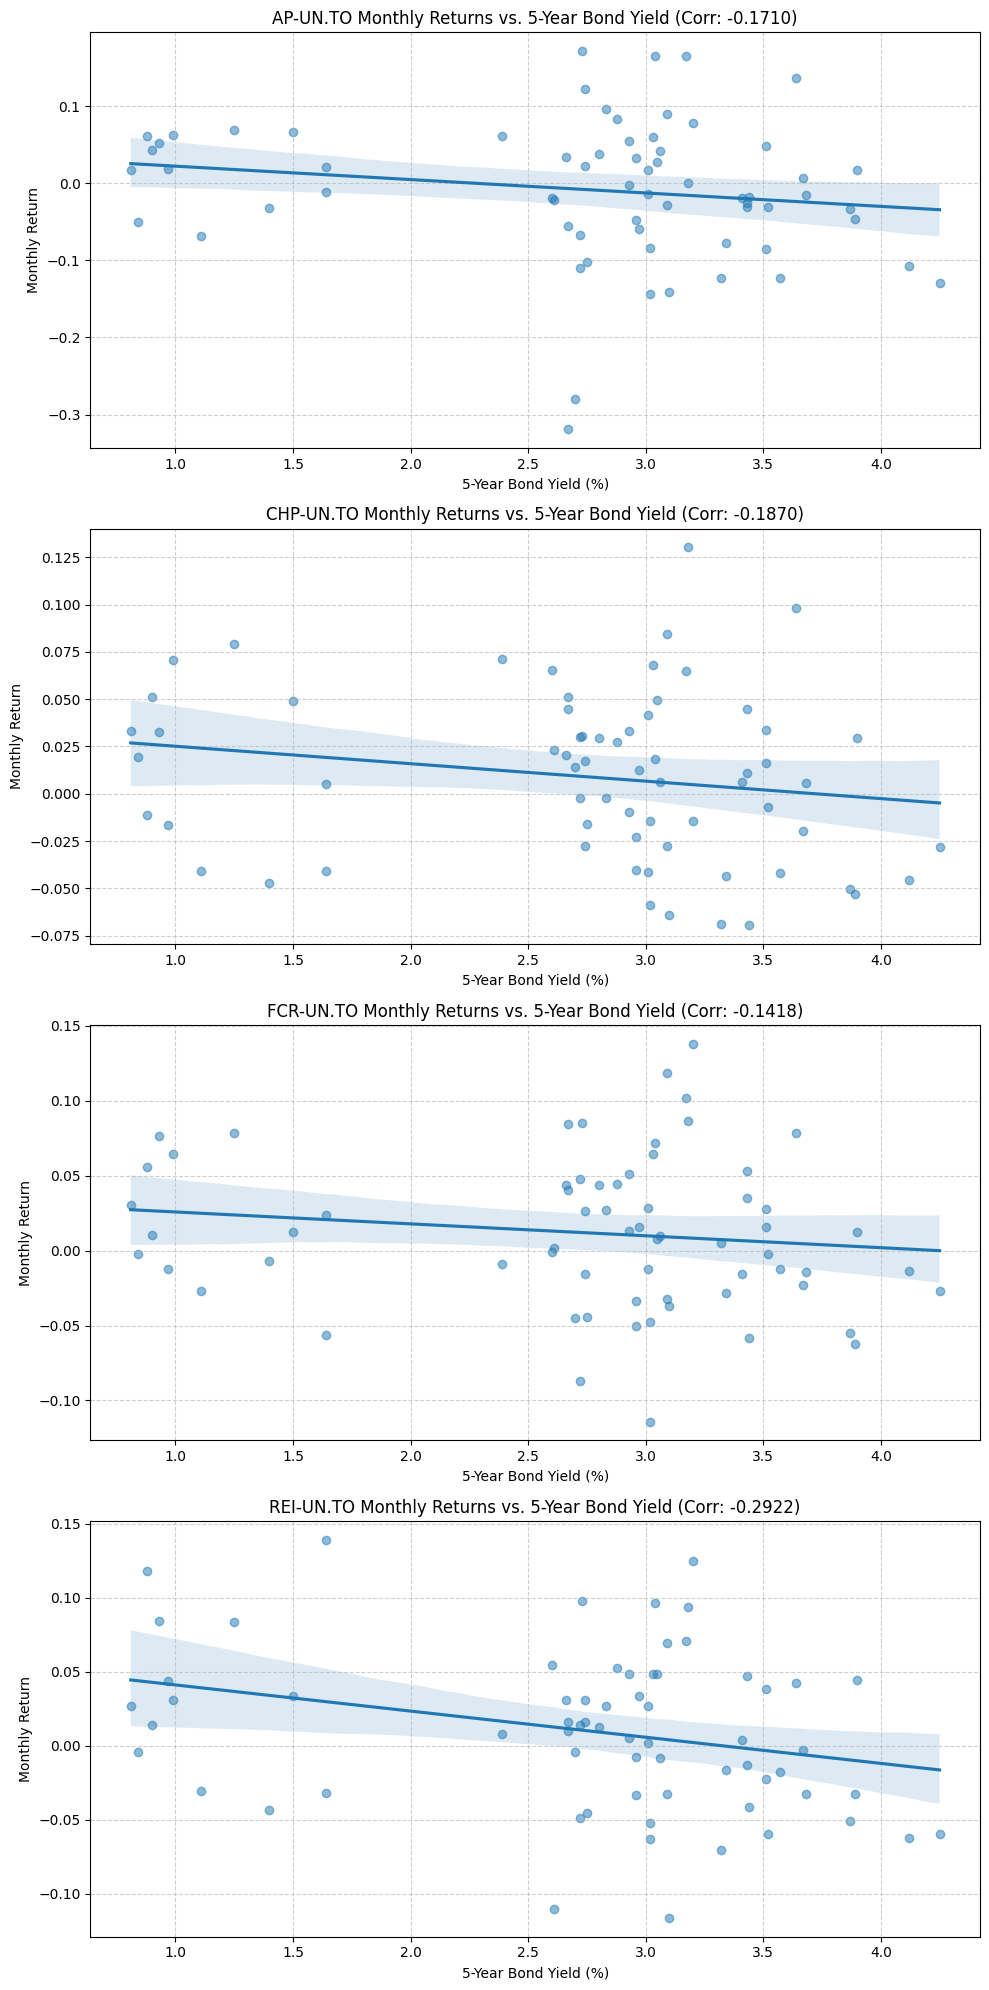

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Re-using the monthly_prices DataFrame which contains all tickers
bond_5yr_series = monthly_macro[['date', '5-year Government of Canada benchmark bond yield']].copy()

# List of other tickers excluding SmartCentres
other_tickers = [t for t in monthly_prices['ticker'].unique() if t != SMARTCENTRES_TICKER]

# Create a multi-plot figure
fig, axes = plt.subplots(len(other_tickers), 1, figsize=(10, 5 * len(other_tickers)))
if len(other_tickers) == 1: axes = [axes]

for i, ticker in enumerate(other_tickers):
    # Get monthly data for this ticker
    ticker_data = monthly_prices[monthly_prices['ticker'] == ticker][['Date', 'monthly_return']].copy()
    ticker_data = ticker_data.rename(columns={'Date': 'date'})

    # Merge with bond data
    combined = pd.merge(ticker_data, bond_5yr_series, on='date', how='inner').dropna()

    # Calculate correlation
    corr = combined['monthly_return'].corr(combined['5-year Government of Canada benchmark bond yield'])

    # Plot
    sns.regplot(
        x='5-year Government of Canada benchmark bond yield',
        y='monthly_return',
        data=combined,
        ax=axes[i],
        scatter_kws={'alpha':0.5}
    )
    axes[i].set_title(f"{ticker} Monthly Returns vs. 5-Year Bond Yield (Corr: {corr:.4f})")
    axes[i].set_xlabel("5-Year Bond Yield (%)")
    axes[i].set_ylabel("Monthly Return")
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### SmartCentres 5-Year Dividend History (2021 - 2025)

This table shows the total cash distribution paid out per unit each year.

In [ ]:
# Filter for the last 5 years and clean up the display
dividend_history = annual_dividends[annual_dividends['year'].between(2021, 2025)].copy()
dividend_history = dividend_history[['year', 'annual_distribution_per_unit', 'payment_count']]

dividend_history.columns = ['Year', 'Total Dividend (CAD)', 'Months Paid']

display(dividend_history.style.format({
    'Total Dividend (CAD)': '${:.3f}'
}))

print("Note: 2025 data reflects payments recorded year-to-date.")